<a href="https://colab.research.google.com/github/ThathsaraGeetha/CompanyB-frontend/blob/main/wind_sequential.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00



=== Horizon 1h Ahead (Sequential: XGB → CatBoost) ===
1h | RMSE=0.1098, MAE=0.0732, R2=0.8805, MAPE_nonzero=62.30%, Acc(MAE)=92.68%

=== Horizon 2h Ahead (Sequential: XGB → CatBoost) ===
2h | RMSE=0.1515, MAE=0.1055, R2=0.7724, MAPE_nonzero=112.66%, Acc(MAE)=89.45%

Forecast Metrics by Horizon:
           RMSE     MAE      R2  MAPE_nonzero  Acc(MAE)
Horizon                                                
1h       0.1098  0.0732  0.8805         62.30     92.68
2h       0.1515  0.1055  0.7724        112.66     89.45


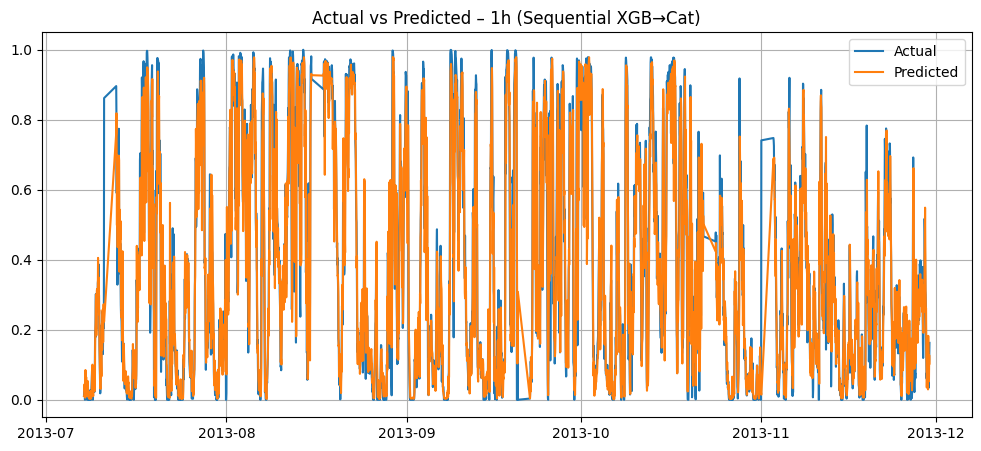

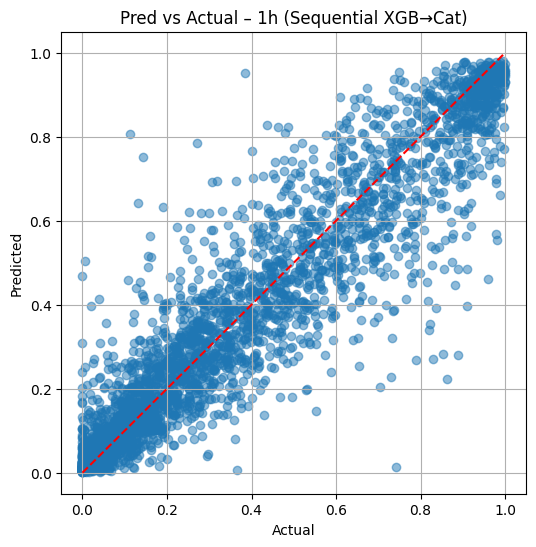

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# =========================
# 1) Load data & timestamp
# =========================
df = pd.read_excel('WindPowerForecastingData TASK.xlsx')
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
df = df.set_index('TIMESTAMP').sort_index()

# =========================
# 2) Feature engineering
# =========================
def add_features(df):
    df = df.copy()

    # wind magnitudes & directions
    df['W10']    = np.hypot(df['U10'], df['V10'])
    df['W100']   = np.hypot(df['U100'], df['V100'])
    df['DIR10']  = np.arctan2(df['V10'], df['U10'])
    df['DIR100'] = np.arctan2(df['V100'], df['U100'])

    # shear & ratios
    df['shear']  = df['W100'] - df['W10']
    df['wratio'] = df['W100'] / (df['W10'] + 1e-6)

    # time features (raw + cyclical)
    df['hour']      = df.index.hour
    df['minute']    = df.index.minute
    df['dayofweek'] = df.index.dayofweek
    df['month']     = df.index.month
    df['is_weekend']= (df['dayofweek'] >= 5).astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['doy']       = df.index.dayofyear
    df['doy_sin']   = np.sin(2 * np.pi * df['doy'] / 365.25)
    df['doy_cos']   = np.cos(2 * np.pi * df['doy'] / 365.25)

    # Fourier harmonics for hour
    df['hour_sin_2'] = np.sin(2 * np.pi * df['hour'] * 2 / 24)
    df['hour_cos_2'] = np.cos(2 * np.pi * df['hour'] * 2 / 24)

    # rolling statistics
    windows = [3, 6, 12, 24, 48]
    for w in windows:
        df[f'W10_rm_{w}']   = df['W10'].rolling(w).mean()
        df[f'W10_rs_{w}']   = df['W10'].rolling(w).std()
        df[f'W10_rmin_{w}'] = df['W10'].rolling(w).min()
        df[f'W10_rmax_{w}'] = df['W10'].rolling(w).max()
        df[f'T_rm_{w}']     = df['TARGETVAR'].rolling(w).mean()
        df[f'T_rs_{w}']     = df['TARGETVAR'].rolling(w).std()

    # EWMs
    df['W10_ewm_3']  = df['W10'].ewm(span=3).mean()
    df['W10_ewm_12'] = df['W10'].ewm(span=12).mean()
    df['W10_ewm_24'] = df['W10'].ewm(span=24).mean()

    # percentiles / IQR
    df['W10_q75_24'] = df['W10'].rolling(24).quantile(0.75)
    df['W10_q25_24'] = df['W10'].rolling(24).quantile(0.25)
    df['W10_iqr_24'] = df['W10_q75_24'] - df['W10_q25_24']

    # lags
    lag_hours = [1,2,3,6,12,24,48]
    for lag in lag_hours:
        df[f'lag_W10_{lag}']    = df['W10'].shift(lag)
        df[f'lag_TARGET_{lag}'] = df['TARGETVAR'].shift(lag)

    # differences
    df['W10_diff_1']    = df['W10'] - df['W10'].shift(1)
    df['W10_diff_3']    = df['W10'] - df['W10'].shift(3)
    df['TARGET_diff_1'] = df['TARGETVAR'] - df['TARGETVAR'].shift(1)

    # normalized power curve proxy
    def power_curve_proxy(ws, cut_in=3.5, rated=12.0):
        p = np.zeros_like(ws, dtype=float)
        mask2 = (ws > cut_in) & (ws < rated)
        mask3 = ws >= rated
        p[mask2] = ((ws[mask2] - cut_in) / (rated - cut_in)) ** 3
        p[mask3] = 1.0
        return p
    df['power_proxy'] = power_curve_proxy(df['W10'].values)

    # interactions
    df['W10_x_hour_sin'] = df['W10'] * df['hour_sin']
    df['shear_x_power']  = df['shear'] * df['power_proxy']
    df['wratio_x_power'] = df['wratio'] * df['power_proxy']

    # turbulence intensity proxies
    df['turb_int_3']  = df['W10_rs_3'] / (df['W10_rm_3'] + 1e-6)
    df['turb_int_12'] = df['W10_rs_12'] / (df['W10_rm_12'] + 1e-6)

    # regime flags
    bins = [0.0, 3.5, 8.0, 25.0]
    df['wind_regime'] = pd.cut(df['W10'], bins=bins, labels=[0,1,2]).astype(float)

    # time since last nonzero target
    nz = (df['TARGETVAR'] > 1e-6).astype(int)
    df['time_since_nz'] = nz.groupby((nz == 0).cumsum()).cumcount().astype(float)

    return df.dropna()

df_fe = add_features(df)

# =========================
# 3) Multi-horizon targets
# =========================
horizons = [1, 2]
for h in horizons:
    df_fe[f'target_h{h}'] = df_fe['TARGETVAR'].shift(-h)
df_fe.dropna(subset=[f'target_h{h}' for h in horizons], inplace=True)

# =========================
# 4) Train/Test split
# =========================
split_idx  = int(len(df_fe) * 0.8)
split_time = df_fe.index[split_idx]
train = df_fe.loc[:split_time]
test  = df_fe.loc[split_time + timedelta(hours=1):]

X_cols = [c for c in df_fe.columns if c != 'TARGETVAR' and not c.startswith('target_h')]

# ===============================
# 5) Sequential ensemble training (XGB → CatBoost)
# ===============================
results   = {}
preds     = {}
actuals   = {}
eps       = 1e-6

for h in horizons:
    print(f"\n=== Horizon {h}h Ahead (Sequential: XGB → CatBoost) ===")
    y_train_full = train[f'target_h{h}']
    y_test_full  = test[f'target_h{h}']

    # inner split for unbiased stage-2 training signal
    idx_val   = int(len(train) * 0.8)
    t_val     = train.index[idx_val]
    tr_in     = train.loc[:t_val]
    val_in    = train.loc[t_val + timedelta(hours=1):]

    y_tr_in   = tr_in[f'target_h{h}']
    y_val_in  = val_in[f'target_h{h}']

    # Stage 1: XGBoost
    xgb_1 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
    xgb_1.fit(tr_in[X_cols], y_tr_in)
    val_pred_xgb = xgb_1.predict(val_in[X_cols])

    # Build stage-2 matrices
    xgb_1_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
    xgb_1_full.fit(train[X_cols], y_train_full)
    train_pred_xgb_full = xgb_1_full.predict(train[X_cols])

    X_train_stage2 = train[X_cols].copy()
    X_train_stage2[f'xgb_pred_h{h}'] = train_pred_xgb_full

    X_val_stage2 = val_in[X_cols].copy()
    X_val_stage2[f'xgb_pred_h{h}'] = val_pred_xgb

    # Stage 2: CatBoost on augmented features
    cat_2 = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
    cat_2.fit(X_train_stage2, y_train_full)

    # Inference
    test_pred_xgb = xgb_1_full.predict(test[X_cols])
    X_test_stage2 = test[X_cols].copy()
    X_test_stage2[f'xgb_pred_h{h}'] = test_pred_xgb
    p_seq = cat_2.predict(X_test_stage2)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_full, p_seq))
    mae  = mean_absolute_error(y_test_full, p_seq)
    r2   = r2_score(y_test_full, p_seq)

    # MAPE (non-zero) and capped accuracy
    mask       = y_test_full > eps
    mape_nz    = np.mean(np.abs((y_test_full[mask] - p_seq[mask]) /
                                (y_test_full[mask] + eps))) * 100
    acc_mape   = max(0, 100 - mape_nz)

    # MAE-based accuracy (capped)
    acc_mae    = max(0, (1 - mae) * 100)

    key = f'{h}h'
    results[key] = {
        'RMSE': round(rmse,4),
        'MAE': round(mae,4),
        'R2': round(r2,4),
        'MAPE_nonzero': round(mape_nz,2),
        'Acc(MAE)': round(acc_mae,2),
    }
    preds[key]   = pd.Series(p_seq, index=test.index)
    actuals[key] = y_test_full

    print(f"{key} | RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"MAPE_nonzero={mape_nz:.2f}%, "
          f"Acc(MAE)={acc_mae:.2f}%")

# =========================
# 6) Summary table
# =========================
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'Horizon'
print("\nForecast Metrics by Horizon:")
print(metrics_df)

# =========================
# 7) Time series & scatter
# =========================
h_sel = '1h'
plt.figure(figsize=(12,5))
plt.plot(actuals[h_sel], label='Actual')
plt.plot(preds[h_sel],   label='Predicted')
plt.title(f'Actual vs Predicted – {h_sel} (Sequential XGB→Cat)')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(6,6))
plt.scatter(actuals[h_sel], preds[h_sel], alpha=0.5)
min_val = min(actuals[h_sel].min(), preds[h_sel].min())
max_val = max(actuals[h_sel].max(), preds[h_sel].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title(f'Pred vs Actual – {h_sel} (Sequential XGB→Cat)')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.grid(); plt.show()


=== Horizon 1h Ahead (Sequential: XGB → CatBoost) ===
1h | RMSE=0.1098, MAE=0.0732, R2=0.8805, Acc(MAE)=92.68%

=== Horizon 2h Ahead (Sequential: XGB → CatBoost) ===
2h | RMSE=0.1515, MAE=0.1055, R2=0.7724, Acc(MAE)=89.45%

Forecast Metrics by Horizon:
           RMSE     MAE      R2  Acc(MAE)
Horizon                                  
1h       0.1098  0.0732  0.8805     92.68
2h       0.1515  0.1055  0.7724     89.45


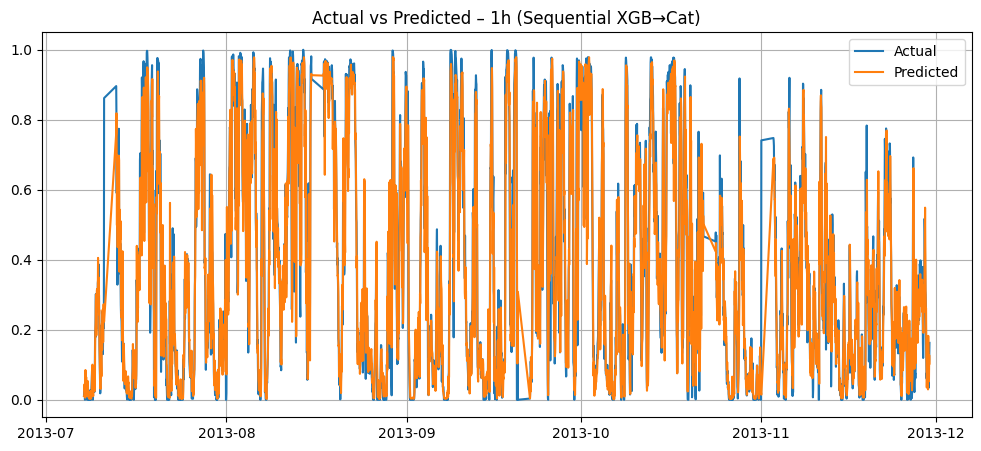

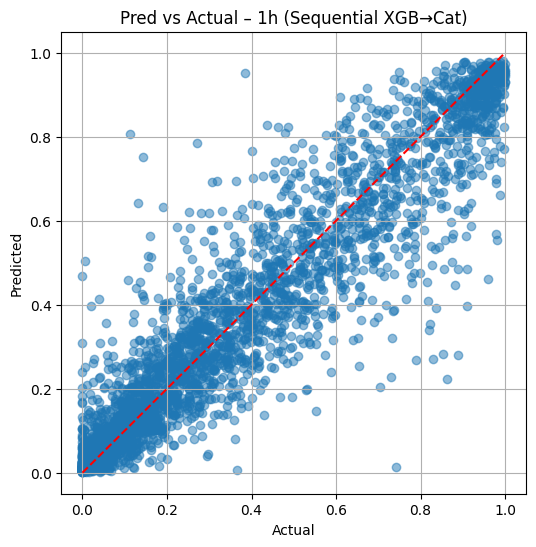

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# =========================
# 1) Load data & timestamp
# =========================
df = pd.read_excel('WindPowerForecastingData TASK.xlsx')
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
df = df.set_index('TIMESTAMP').sort_index()

# =========================
# 2) Feature engineering
# =========================
def add_features(df):
    df = df.copy()

    # wind magnitudes & directions
    df['W10']    = np.hypot(df['U10'], df['V10'])
    df['W100']   = np.hypot(df['U100'], df['V100'])
    df['DIR10']  = np.arctan2(df['V10'], df['U10'])
    df['DIR100'] = np.arctan2(df['V100'], df['U100'])

    # shear & ratios
    df['shear']  = df['W100'] - df['W10']
    df['wratio'] = df['W100'] / (df['W10'] + 1e-6)

    # time features (raw + cyclical)
    df['hour']      = df.index.hour
    df['minute']    = df.index.minute
    df['dayofweek'] = df.index.dayofweek
    df['month']     = df.index.month
    df['is_weekend']= (df['dayofweek'] >= 5).astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['doy']       = df.index.dayofyear
    df['doy_sin']   = np.sin(2 * np.pi * df['doy'] / 365.25)
    df['doy_cos']   = np.cos(2 * np.pi * df['doy'] / 365.25)

    # Fourier harmonics for hour
    df['hour_sin_2'] = np.sin(2 * np.pi * df['hour'] * 2 / 24)
    df['hour_cos_2'] = np.cos(2 * np.pi * df['hour'] * 2 / 24)

    # rolling statistics
    windows = [3, 6, 12, 24, 48]
    for w in windows:
        df[f'W10_rm_{w}']   = df['W10'].rolling(w).mean()
        df[f'W10_rs_{w}']   = df['W10'].rolling(w).std()
        df[f'W10_rmin_{w}'] = df['W10'].rolling(w).min()
        df[f'W10_rmax_{w}'] = df['W10'].rolling(w).max()
        df[f'T_rm_{w}']     = df['TARGETVAR'].rolling(w).mean()
        df[f'T_rs_{w}']     = df['TARGETVAR'].rolling(w).std()

    # EWMs
    df['W10_ewm_3']  = df['W10'].ewm(span=3).mean()
    df['W10_ewm_12'] = df['W10'].ewm(span=12).mean()
    df['W10_ewm_24'] = df['W10'].ewm(span=24).mean()

    # percentiles / IQR
    df['W10_q75_24'] = df['W10'].rolling(24).quantile(0.75)
    df['W10_q25_24'] = df['W10'].rolling(24).quantile(0.25)
    df['W10_iqr_24'] = df['W10_q75_24'] - df['W10_q25_24']

    # lags
    lag_hours = [1,2,3,6,12,24,48]
    for lag in lag_hours:
        df[f'lag_W10_{lag}']    = df['W10'].shift(lag)
        df[f'lag_TARGET_{lag}'] = df['TARGETVAR'].shift(lag)

    # differences
    df['W10_diff_1']    = df['W10'] - df['W10'].shift(1)
    df['W10_diff_3']    = df['W10'] - df['W10'].shift(3)
    df['TARGET_diff_1'] = df['TARGETVAR'] - df['TARGETVAR'].shift(1)

    # normalized power curve proxy
    def power_curve_proxy(ws, cut_in=3.5, rated=12.0):
        p = np.zeros_like(ws, dtype=float)
        mask2 = (ws > cut_in) & (ws < rated)
        mask3 = ws >= rated
        p[mask2] = ((ws[mask2] - cut_in) / (rated - cut_in)) ** 3
        p[mask3] = 1.0
        return p
    df['power_proxy'] = power_curve_proxy(df['W10'].values)

    # interactions
    df['W10_x_hour_sin'] = df['W10'] * df['hour_sin']
    df['shear_x_power']  = df['shear'] * df['power_proxy']
    df['wratio_x_power'] = df['wratio'] * df['power_proxy']

    # turbulence intensity proxies
    df['turb_int_3']  = df['W10_rs_3'] / (df['W10_rm_3'] + 1e-6)
    df['turb_int_12'] = df['W10_rs_12'] / (df['W10_rm_12'] + 1e-6)

    # regime flags
    bins = [0.0, 3.5, 8.0, 25.0]
    df['wind_regime'] = pd.cut(df['W10'], bins=bins, labels=[0,1,2]).astype(float)

    # time since last nonzero target
    nz = (df['TARGETVAR'] > 1e-6).astype(int)
    df['time_since_nz'] = nz.groupby((nz == 0).cumsum()).cumcount().astype(float)

    return df.dropna()

df_fe = add_features(df)

# =========================
# 3) Multi-horizon targets
# =========================
horizons = [1, 2]
for h in horizons:
    df_fe[f'target_h{h}'] = df_fe['TARGETVAR'].shift(-h)
df_fe.dropna(subset=[f'target_h{h}' for h in horizons], inplace=True)

# =========================
# 4) Train/Test split
# =========================
split_idx  = int(len(df_fe) * 0.8)
split_time = df_fe.index[split_idx]
train = df_fe.loc[:split_time]
test  = df_fe.loc[split_time + timedelta(hours=1):]

X_cols = [c for c in df_fe.columns if c != 'TARGETVAR' and not c.startswith('target_h')]

# ===============================
# 5) Sequential ensemble training (XGB → CatBoost)
# ===============================
results   = {}
preds     = {}
actuals   = {}
eps       = 1e-6

for h in horizons:
    print(f"\n=== Horizon {h}h Ahead (Sequential: XGB → CatBoost) ===")
    y_train_full = train[f'target_h{h}']
    y_test_full  = test[f'target_h{h}']

    # inner split for unbiased stage-2 training signal
    idx_val   = int(len(train) * 0.8)
    t_val     = train.index[idx_val]
    tr_in     = train.loc[:t_val]
    val_in    = train.loc[t_val + timedelta(hours=1):]

    y_tr_in   = tr_in[f'target_h{h}']
    y_val_in  = val_in[f'target_h{h}']

    # Stage 1: XGBoost
    xgb_1 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
    xgb_1.fit(tr_in[X_cols], y_tr_in)
    val_pred_xgb = xgb_1.predict(val_in[X_cols])

    # Build stage-2 matrices
    xgb_1_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
    xgb_1_full.fit(train[X_cols], y_train_full)
    train_pred_xgb_full = xgb_1_full.predict(train[X_cols])

    X_train_stage2 = train[X_cols].copy()
    X_train_stage2[f'xgb_pred_h{h}'] = train_pred_xgb_full

    X_val_stage2 = val_in[X_cols].copy()
    X_val_stage2[f'xgb_pred_h{h}'] = val_pred_xgb

    # Stage 2: CatBoost on augmented features
    cat_2 = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
    cat_2.fit(X_train_stage2, y_train_full)

    # Inference
    test_pred_xgb = xgb_1_full.predict(test[X_cols])
    X_test_stage2 = test[X_cols].copy()
    X_test_stage2[f'xgb_pred_h{h}'] = test_pred_xgb
    p_seq = cat_2.predict(X_test_stage2)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_full, p_seq))
    mae  = mean_absolute_error(y_test_full, p_seq)
    r2   = r2_score(y_test_full, p_seq)

    # MAE-based accuracy (capped)
    acc_mae    = max(0, (1 - mae) * 100)

    key = f'{h}h'
    results[key] = {
        'RMSE': round(rmse,4),
        'MAE': round(mae,4),
        'R2': round(r2,4),
        'Acc(MAE)': round(acc_mae,2),
    }
    preds[key]   = pd.Series(p_seq, index=test.index)
    actuals[key] = y_test_full

    print(f"{key} | RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"Acc(MAE)={acc_mae:.2f}%")

# =========================
# 6) Summary table
# =========================
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'Horizon'
print("\nForecast Metrics by Horizon:")
print(metrics_df)

# =========================
# 7) Time series & scatter
# =========================
h_sel = '1h'
plt.figure(figsize=(12,5))
plt.plot(actuals[h_sel], label='Actual')
plt.plot(preds[h_sel],   label='Predicted')
plt.title(f'Actual vs Predicted – {h_sel} (Sequential XGB→Cat)')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(6,6))
plt.scatter(actuals[h_sel], preds[h_sel], alpha=0.5)
min_val = min(actuals[h_sel].min(), preds[h_sel].min())
max_val = max(actuals[h_sel].max(), preds[h_sel].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title(f'Pred vs Actual – {h_sel} (Sequential XGB→Cat)')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.grid(); plt.show()